# Pipeline 3 — Temporal Particle Tracking End-to-End Test

This notebook processes a multi-frame sequence through the full Pipeline 3:
- Frame 0: Pipeline 1 cold-start (BestFirstSearcher)
- Frame 1+: IMU-predicted particle-guided two-pass search + meta-tile + semantic confirmation

Outputs: JSONL logs, meta-tiles, trajectory CSV, summary metrics.

In [1]:
# Cell 1 — Setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import config
from src.tile_utils import TileLoader, haversine_distance
from src.image_utils import load_image
from src.geometric_matcher import initialize_matcher
from src.semantic_model import load_semantic_model
from src.temporal_searcher import TemporalSearcher
from src.ekf_ins import preprocess_imu_csv

config.ensure_output_dirs()
print('Setup complete')

Setup complete


In [2]:
# Cell 2 — Load Video Sequence & IMU data + EKF preprocessing
from src.ekf_ins import preprocess_imu_csv
from src.tile_utils import tile_to_latlon

# Run Error-State EKF to get dead-reckoned positions
imu_log = preprocess_imu_csv(config.IMU_CSV_PATH)
print(f'IMU log: {len(imu_log)} rows')
print(f'Columns: {imu_log.columns.tolist()}')

# Build frame list: match CSV timestamps to frame files
frame_dir = config.QUERY_FRAMES_DIR
frame_files = sorted(frame_dir.glob('frame_*.jpg'))
print(f'Found {len(frame_files)} frames in {frame_dir}')

# Map rounded timestamp -> frame path
frame_map = {}
for fp in frame_files:
    ts_str = fp.stem.replace('frame_', '')
    try:
        ts = float(ts_str)
        frame_map[round(ts, 3)] = fp
    except ValueError:
        continue

# Auto-detect START_ROW: first row where GPS is inside the reference map tile bounds
# In TMS: higher Y = more north. tile_to_latlon returns SW corner for integer tiles.
south_lat, west_lon = tile_to_latlon(config.TILE_X_MIN, config.TILE_Y_MIN, config.TMS_ZOOM_LEVEL)
north_lat, _ = tile_to_latlon(config.TILE_X_MIN, config.TILE_Y_MAX + 1, config.TMS_ZOOM_LEVEL)
_, east_lon = tile_to_latlon(config.TILE_X_MAX + 1, config.TILE_Y_MIN, config.TMS_ZOOM_LEVEL)

map_bounds = {
    'lat_min': south_lat,
    'lat_max': north_lat,
    'lon_min': west_lon,
    'lon_max': east_lon,
}
print(f'Reference map bounds: lat [{map_bounds["lat_min"]:.4f}, {map_bounds["lat_max"]:.4f}], '
      f'lon [{map_bounds["lon_min"]:.4f}, {map_bounds["lon_max"]:.4f}]')

START_ROW = 0
for idx in range(len(imu_log)):
    row = imu_log.iloc[idx]
    lat = row['gps_lat']
    lon = row['gps_lon']
    if (map_bounds['lat_min'] <= lat <= map_bounds['lat_max'] and
        map_bounds['lon_min'] <= lon <= map_bounds['lon_max']):
        START_ROW = idx
        break
print(f'Auto-detected START_ROW = {START_ROW} (first GPS inside reference map)')

NUM_FRAMES = 300

aligned = []
for idx in range(START_ROW, len(imu_log)):
    row = imu_log.iloc[idx]
    ts_rounded = round(row['timestamp'], 3)
    if ts_rounded in frame_map:
        aligned.append((idx, row['timestamp'], frame_map[ts_rounded]))
    if len(aligned) >= NUM_FRAMES:
        break

print(f'Aligned {len(aligned)} frame-IMU pairs (starting from row {START_ROW})')
if aligned:
    print(f'First: ts={aligned[0][1]:.3f}  Last: ts={aligned[-1][1]:.3f}')
    r0 = imu_log.iloc[aligned[0][0]]
    print(f'First frame GPS: ({r0["gps_lat"]:.6f}, {r0["gps_lon"]:.6f})')
    print(f'First frame EKF: ({r0["latitude_est"]:.6f}, {r0["longitude_est"]:.6f})')

IMU log: 970 rows
Columns: ['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'gps_lat', 'gps_lon', 'gps_alt', 'pitch', 'bank', 'heading', 'pressure_altitude', 'barometer_pressure', 'heading_magnetic', 'magnetic_compass', 'airspeed_indicated', 'airspeed_true', 'ground_velocity', 'vertical_speed', 'ap_master', 'ap_alt_hold', 'ap_airspeed_hold', 'ap_nav_hold', 'throttle_pos', 'latitude_est', 'longitude_est', 'altitude_est', 'pos_n', 'pos_e', 'pos_d', 'vel_n', 'vel_e', 'vel_d', 'roll_deg', 'pitch_deg', 'yaw_deg', 'gyro_bias_x', 'gyro_bias_y', 'gyro_bias_z', 'wind_n', 'wind_e']
Found 969 frames in C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Logs_Run_20260321_162024\images_20260321_162024
Reference map bounds: lat [55.6807, 55.7364], lon [9.4812, 9.5636]
Auto-detected START_ROW = 430 (first GPS inside reference map)
Aligned 300 frame-IMU pairs (starting from row 430)
First: ts=199.325  Last: ts=334.797
First frame GPS: (55.680738, 9.558186)
First frame EKF:

In [3]:
# Cell 3 — Initialize Temporal Searcher
semantic_model = load_semantic_model(config.SEMANTIC_MODEL_PATH, config.DEVICE)
matcher = initialize_matcher(config.DEVICE, config.MAX_NUM_KEYPOINTS)
tile_loader = TileLoader(
    config.REFERENCE_TILES_DIR,
    config.REFERENCE_PRED_DIR,
    zoom=config.TMS_ZOOM_LEVEL,
    x_range=(config.TILE_X_MIN, config.TILE_X_MAX),
    y_range=(config.TILE_Y_MIN, config.TILE_Y_MAX),
)
print(f'Tiles available: {len(tile_loader.list_tiles())}')

searcher = TemporalSearcher(semantic_model, matcher, tile_loader, config)
print('TemporalSearcher initialized')

Tiles available: 3960
TemporalSearcher initialized


In [4]:
# Cell 2.5 — EKF Sanity Check: compare EKF estimates vs GPS ground truth
from src.tile_utils import haversine_distance

# Check EKF drift for aligned frames
ekf_errors = []
for csv_idx, ts, _ in aligned:
    row = imu_log.iloc[csv_idx]
    d = haversine_distance(row['latitude_est'], row['longitude_est'],
                           row['gps_lat'], row['gps_lon'])
    ekf_errors.append(d)

ekf_errors = np.array(ekf_errors)
print(f'EKF vs GPS drift (for {len(aligned)} aligned frames):')
print(f'  Mean:    {ekf_errors.mean():.1f} m')
print(f'  Median:  {np.median(ekf_errors):.1f} m')
print(f'  Min:     {ekf_errors.min():.1f} m')
print(f'  Max:     {ekf_errors.max():.1f} m')
print(f'  Std:     {ekf_errors.std():.1f} m')

# Check heading
yaw_samples = [imu_log.iloc[a[0]]['yaw_deg'] for a in aligned[:5]]
heading_samples = [imu_log.iloc[a[0]]['heading'] for a in aligned[:5]]
print(f'\nFirst 5 EKF yaw_deg:     {[f"{y:.1f}" for y in yaw_samples]}')
print(f'First 5 raw heading:     {[f"{h:.4f}" for h in heading_samples]}')
print(f'(raw heading is in radians from SimConnect)')

# Check velocity
vel_samples = [(imu_log.iloc[a[0]]['vel_n'], imu_log.iloc[a[0]]['vel_e']) for a in aligned[:5]]
speed_samples = [np.sqrt(vn**2 + ve**2) for vn, ve in vel_samples]
print(f'\nFirst 5 speeds (m/s):    {[f"{s:.1f}" for s in speed_samples]}')

EKF vs GPS drift (for 300 aligned frames):
  Mean:    192.6 m
  Median:  194.4 m
  Min:     158.9 m
  Max:     223.0 m
  Std:     18.6 m

First 5 EKF yaw_deg:     ['-61.6', '-61.7', '-61.8', '-61.9', '-61.9']
First 5 raw heading:     ['5.2088', '5.2078', '5.2064', '5.2051', '5.2038']
(raw heading is in radians from SimConnect)

First 5 speeds (m/s):    ['67.0', '67.0', '67.0', '67.0', '67.0']


In [5]:
# Cell 4 — Process All Frames (using EKF dead-reckoned positions)
results = []

for i, (csv_idx, ts, frame_path) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    query_frame = load_image(frame_path)

    # Use EKF dead-reckoned positions (correct column names from preprocess_imu_csv)
    ekf_lat = row['latitude_est']
    ekf_lon = row['longitude_est']
    ekf_yaw_deg = row['yaw_deg']  # already in degrees

    # Velocity from EKF columns
    if 'vel_n' in row.index and 'vel_e' in row.index:
        vel = np.sqrt(row['vel_n']**2 + row['vel_e']**2)
    elif 'airspeed_true' in row.index:
        vel = row['airspeed_true']
    else:
        vel = 20.0

    gyro_z_dps = row.get('gyro_z', 0.0) * (180.0 / np.pi)

    imu_data = {
        'lat': ekf_lat,
        'lon': ekf_lon,
        'heading': ekf_yaw_deg,  # already degrees
        'pos_sigma': 100.0,
        'heading_sigma': 15.0,
        'velocity_mps': vel,
        'gyro_z_dps': gyro_z_dps,
    }

    result = searcher.process_frame(query_frame, imu_data, timestamp=ts)
    results.append(result)

    if i % 10 == 0 or i < 5:
        verified = result.get('meta_tile_verified', 'N/A')
        sem_conf = result.get('semantic_confidence', 0) or 0
        print(f'Frame {i:3d} | {result["method"]:20s} | tiles={result["tiles_tested"]:3d} | '
              f't={result["search_time"]:.2f}s | verified={verified} | sem={sem_conf:.3f}')

searcher.close()
print(f'\nProcessed {len(results)} frames')

Frame   0 | cold_start           | tiles=  4 | t=2.70s | verified=None | sem=0.000
Frame   1 | temporal_tracking    | tiles= 11 | t=4.62s | verified=False | sem=0.323
Frame   2 | temporal_tracking    | tiles=  9 | t=3.60s | verified=False | sem=0.460
Frame   3 | temporal_tracking    | tiles=  8 | t=3.50s | verified=False | sem=0.443
Frame   4 | temporal_tracking    | tiles=  7 | t=3.23s | verified=True | sem=0.458
Frame  10 | temporal_tracking    | tiles=  6 | t=3.10s | verified=False | sem=0.505
Frame  20 | temporal_tracking    | tiles=  5 | t=3.19s | verified=True | sem=0.441
Frame  30 | temporal_tracking    | tiles=  7 | t=3.28s | verified=True | sem=0.404
Frame  40 | temporal_tracking    | tiles=  8 | t=3.12s | verified=False | sem=0.281
Frame  50 | temporal_tracking    | tiles=  7 | t=2.85s | verified=False | sem=0.303
Frame  60 | temporal_tracking    | tiles=  7 | t=2.92s | verified=False | sem=0.422
Frame  70 | temporal_tracking    | tiles=  6 | t=2.94s | verified=True | sem=0.5

In [ ]:
# Cell 5 — Analyze Performance (timing & tile counts)
frame0_time = results[0]['search_time']
subsequent_times = [r['search_time'] for r in results[1:]]
mean_sub = np.mean(subsequent_times) if subsequent_times else 0

print(f'Frame 0 time:           {frame0_time:.2f}s')
print(f'Subsequent mean time:   {mean_sub:.2f}s')
if mean_sub > 0:
    print(f'Speedup:                {frame0_time / mean_sub:.1f}x')

frame0_tiles = results[0]['tiles_tested']
subsequent_tiles = [r['tiles_tested'] for r in results[1:]]
mean_sub_tiles = np.mean(subsequent_tiles) if subsequent_tiles else 0

print(f'Frame 0 tiles:          {frame0_tiles}')
print(f'Subsequent mean tiles:  {mean_sub_tiles:.1f}')
if mean_sub_tiles > 0:
    print(f'Tile reduction:         {frame0_tiles / mean_sub_tiles:.1f}x')

In [6]:
# Cell 6 — Compute Accuracy vs Ground Truth (using gps_lat/gps_lon from simulator)
errors = []
for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    gt_lat = row['gps_lat']
    gt_lon = row['gps_lon']

    pos = results[i].get('position')
    if pos is None or pos[0] is None:
        errors.append(float('nan'))
        continue
    est_lat, est_lon = pos
    error_m = haversine_distance(est_lat, est_lon, gt_lat, gt_lon)
    errors.append(error_m)

errors_arr = np.array(errors)
valid = ~np.isnan(errors_arr)

print(f'Frames with position estimate: {valid.sum()} / {len(errors_arr)}')
print(f'Mean error:      {np.nanmean(errors_arr):.1f} m')
print(f'Median error:    {np.nanmedian(errors_arr):.1f} m')
print(f'95th percentile: {np.nanpercentile(errors_arr, 95):.1f} m')
for thresh in config.EVALUATION_THRESHOLDS:
    pct = (errors_arr[valid] < thresh).mean() * 100 if valid.sum() > 0 else 0
    print(f'  < {thresh:4d}m: {pct:.1f}%')

Frames with position estimate: 300 / 300
Mean error:      188.6 m
Median error:    193.3 m
95th percentile: 219.2 m
  <   10m: 0.3%
  <   25m: 0.3%
  <   50m: 1.0%
  <  100m: 1.7%
  <  250m: 100.0%
  <  500m: 100.0%


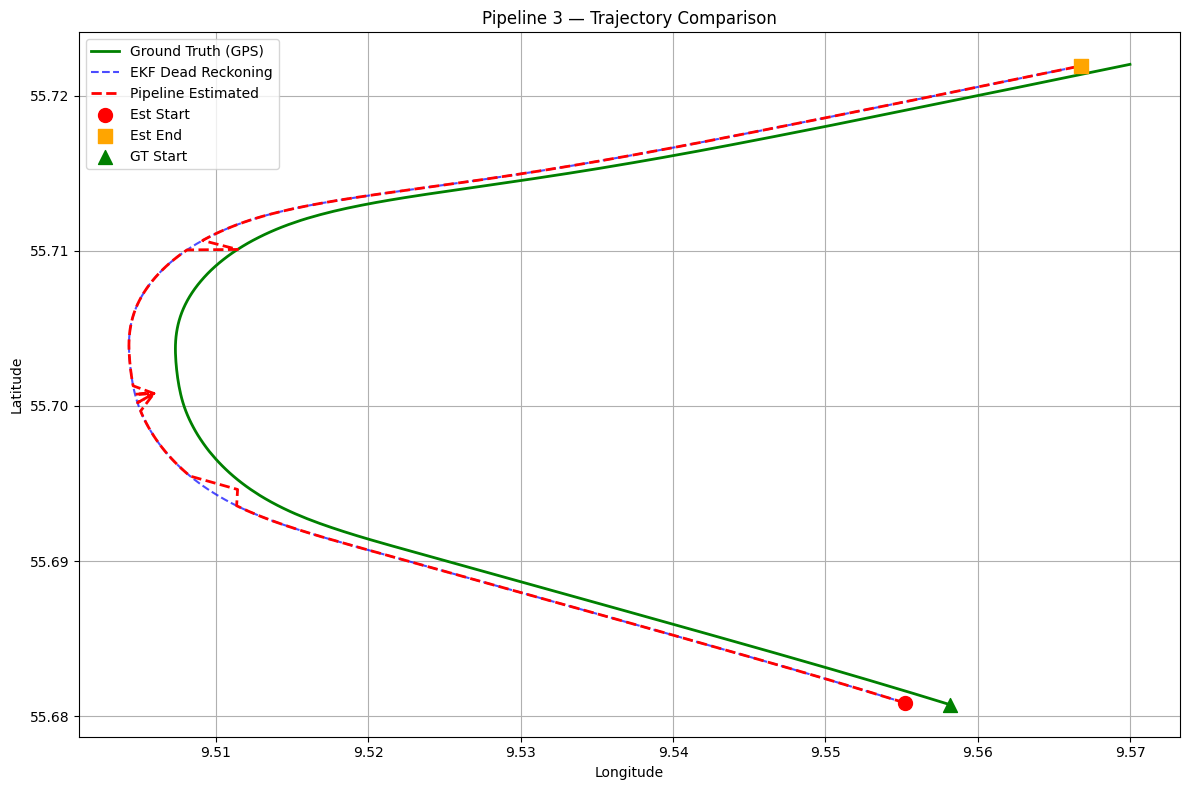

In [8]:
# Cell 7 — Visualize Trajectory
est_lats = [r['position'][0] for r in results if r.get('position') and r['position'][0]]
est_lons = [r['position'][1] for r in results if r.get('position') and r['position'][1]]
gt_lats = [imu_log.iloc[a[0]]['gps_lat'] for a in aligned]
gt_lons = [imu_log.iloc[a[0]]['gps_lon'] for a in aligned]

# Also plot EKF dead-reckoned trajectory for comparison
ekf_lats = [imu_log.iloc[a[0]]['latitude_est'] for a in aligned]
ekf_lons = [imu_log.iloc[a[0]]['longitude_est'] for a in aligned]

plt.figure(figsize=(12, 8))
plt.plot(gt_lons, gt_lats, 'g-', label='Ground Truth (GPS)', linewidth=2)
plt.plot(ekf_lons, ekf_lats, 'b--', label='EKF Dead Reckoning', linewidth=1.5, alpha=0.7)
if est_lons:
    plt.plot(est_lons, est_lats, 'r--', label='Pipeline Estimated', linewidth=2)
    plt.scatter(est_lons[0], est_lats[0], c='red', s=100, marker='o', label='Est Start', zorder=5)
    plt.scatter(est_lons[-1], est_lats[-1], c='orange', s=100, marker='s', label='Est End', zorder=5)
plt.scatter(gt_lons[0], gt_lats[0], c='green', s=100, marker='^', label='GT Start', zorder=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pipeline 3 — Trajectory Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(str(config.TRAJECTORY_OUTPUT_DIR / 'trajectory_comparison.png'), dpi=150)
plt.show()

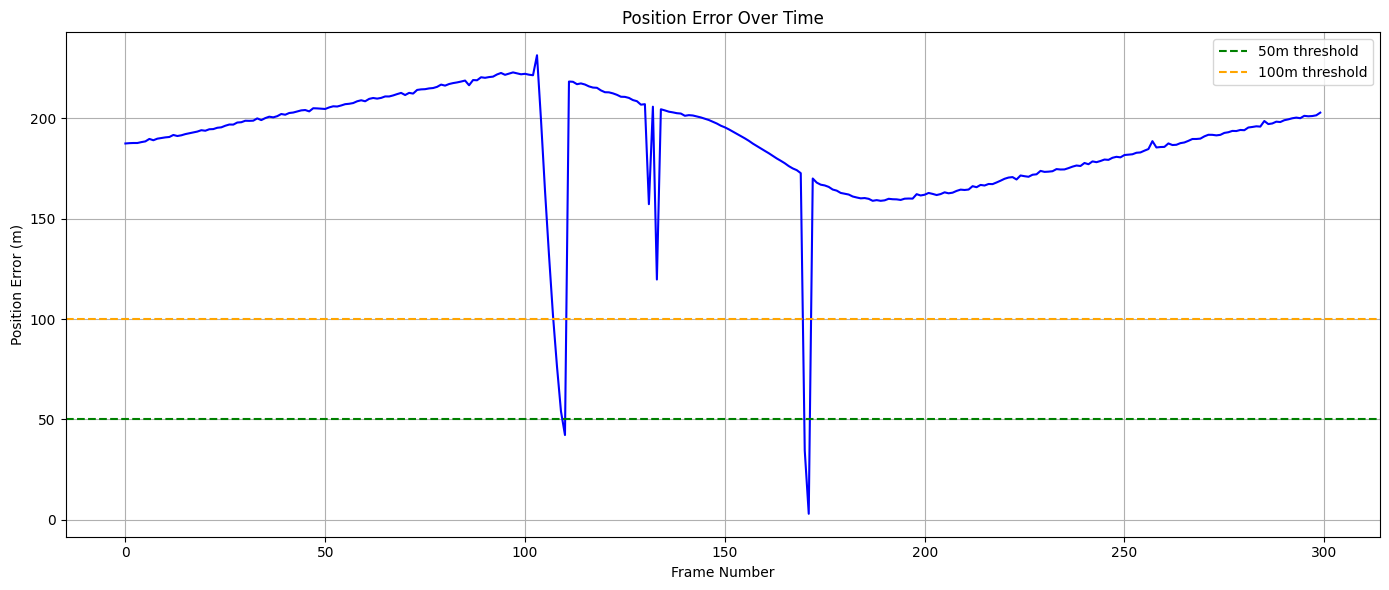

In [9]:
# Cell 8 — Error Timeline
plt.figure(figsize=(14, 6))
plt.plot(errors_arr, 'b-', linewidth=1.5)
plt.axhline(y=50, color='g', linestyle='--', label='50m threshold')
plt.axhline(y=100, color='orange', linestyle='--', label='100m threshold')
plt.xlabel('Frame Number')
plt.ylabel('Position Error (m)')
plt.title('Position Error Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(str(config.TRAJECTORY_OUTPUT_DIR / 'error_timeline.png'), dpi=150)
plt.show()

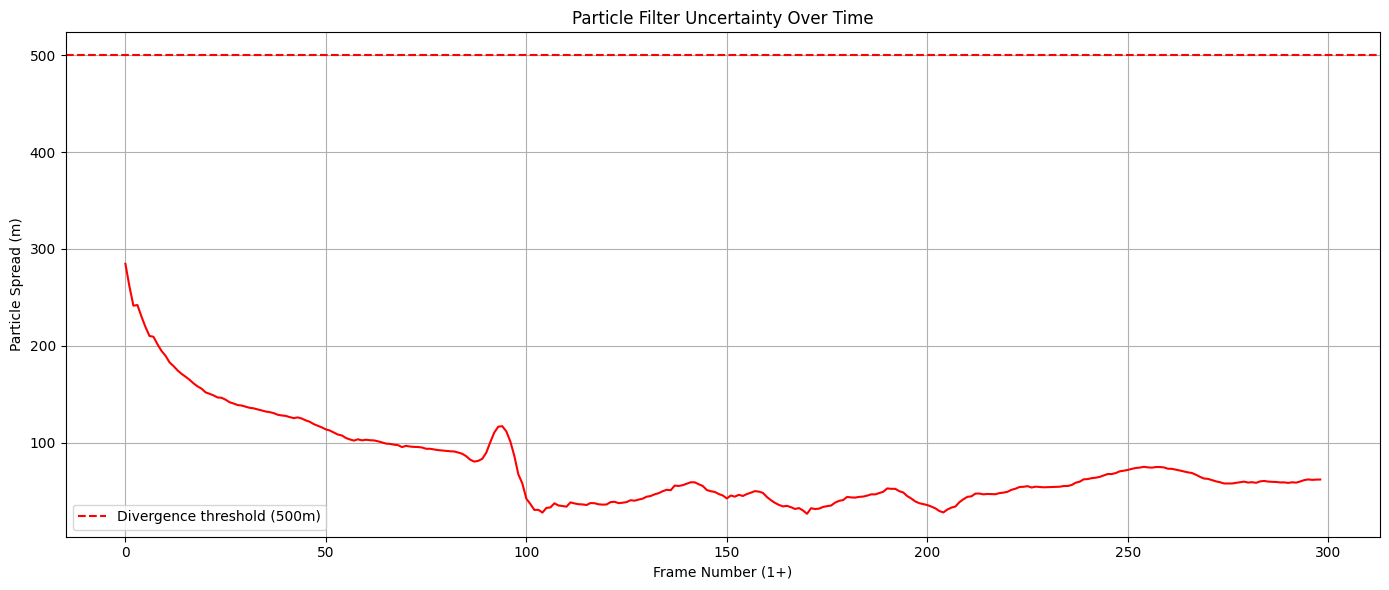


Method distribution:
  temporal_tracking        :  299 (99.7%)
  cold_start               :    1 (0.3%)

Tile matching:
  Frames with >0 tiles: 300/300 (100.0%)
  Mean tiles (when >0):  6.9
  Max tiles:             11


In [10]:
# Cell 9 — Particle Spread Analysis
spreads = [r.get('particle_spread') for r in results[1:] if r.get('particle_spread') is not None]

if spreads:
    plt.figure(figsize=(14, 6))
    plt.plot(spreads, 'r-', linewidth=1.5)
    plt.axhline(y=config.DIVERGENCE_POSITION_THRESHOLD_M, color='red', linestyle='--',
                label=f'Divergence threshold ({config.DIVERGENCE_POSITION_THRESHOLD_M:.0f}m)')
    plt.xlabel('Frame Number (1+)')
    plt.ylabel('Particle Spread (m)')
    plt.title('Particle Filter Uncertainty Over Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(str(config.TRAJECTORY_OUTPUT_DIR / 'particle_spread.png'), dpi=150)
    plt.show()
else:
    print('No particle spread data available')

# Method distribution
from collections import Counter
methods = Counter(r['method'] for r in results)
print(f'\nMethod distribution:')
for method, count in methods.most_common():
    print(f'  {method:25s}: {count:4d} ({count/len(results)*100:.1f}%)')

# Tile match statistics
tiles_tested = [r['tiles_tested'] for r in results]
tiles_nonzero = [t for t in tiles_tested if t > 0]
print(f'\nTile matching:')
print(f'  Frames with >0 tiles: {len(tiles_nonzero)}/{len(tiles_tested)} ({len(tiles_nonzero)/len(tiles_tested)*100:.1f}%)')
if tiles_nonzero:
    print(f'  Mean tiles (when >0):  {np.mean(tiles_nonzero):.1f}')
    print(f'  Max tiles:             {max(tiles_nonzero)}')

In [7]:
# Cell 9b — Deep Diagnostic Analysis
import json as _json

# 1. Per-method error breakdown
method_errors = {}
for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    pos = results[i].get('position')
    if pos is None or pos[0] is None:
        continue
    method = results[i]['method']
    err = haversine_distance(pos[0], pos[1], row['gps_lat'], row['gps_lon'])
    method_errors.setdefault(method, []).append(err)

print("=== Error by Method ===")
for m, errs in sorted(method_errors.items()):
    arr = np.array(errs)
    print(f"  {m:25s}: n={len(arr):3d}  mean={arr.mean():.0f}m  "
          f"median={np.median(arr):.0f}m  min={arr.min():.0f}m  max={arr.max():.0f}m")

# 2. Check dt values (should NOT be 0 anymore after fix)
print("\n=== dt (time delta) Check ===")
log_file = list(config.LOG_OUTPUT_DIR.glob("pipeline3_run_*.jsonl"))
if log_file:
    log_file = sorted(log_file)[-1]  # latest
    with open(log_file) as f:
        log_lines = [_json.loads(l) for l in f.readlines()]
    dts = [l['dt'] for l in log_lines if l['dt'] is not None]
    if dts:
        print(f"  N={len(dts)}  mean_dt={np.mean(dts):.4f}s  "
              f"min_dt={min(dts):.4f}s  max_dt={max(dts):.4f}s")
        dt_zero_count = sum(1 for d in dts if d == 0.0)
        print(f"  dt=0 count: {dt_zero_count} (should be 0 after fix)")
    
    # 3. Mode distribution over time (rolling window)
    modes_timeline = [l['mode'] for l in log_lines]
    imu_fb_count = sum(1 for m in modes_timeline if m == 'imu_fallback')
    tracking_count = sum(1 for m in modes_timeline if m == 'temporal_tracking')
    cold_count = sum(1 for m in modes_timeline if m == 'cold_start')
    print(f"\n=== Mode Distribution ===")
    print(f"  temporal_tracking: {tracking_count} ({tracking_count/len(log_lines)*100:.1f}%)")
    print(f"  imu_fallback:      {imu_fb_count} ({imu_fb_count/len(log_lines)*100:.1f}%)")
    print(f"  cold_start:        {cold_count}")
    
    # 4. Consecutive imu_fallback stretches
    fb_lengths = []
    cur_len = 0
    for m in modes_timeline:
        if m == 'imu_fallback':
            cur_len += 1
        else:
            if cur_len > 0:
                fb_lengths.append(cur_len)
            cur_len = 0
    if cur_len > 0:
        fb_lengths.append(cur_len)
    if fb_lengths:
        print(f"\n=== IMU Fallback Streaks ===")
        print(f"  Count: {len(fb_lengths)} streaks")
        print(f"  Lengths: mean={np.mean(fb_lengths):.1f} max={max(fb_lengths)} total={sum(fb_lengths)}")
    
    # 5. Homography success rate
    homo_success = sum(1 for l in log_lines 
                       if l.get('estimated_lat') is not None 
                       and l['mode'] == 'temporal_tracking')
    print(f"\n=== Position Estimation ===")
    print(f"  Frames with estimated position: {homo_success}/{len(log_lines)}")

# 6. Tile match consistency — are matched tiles near the actual GPS position?
print("\n=== Tile Match Accuracy (matched tile vs actual GPS) ===")
tile_errors = []
for i, (csv_idx, ts, _) in enumerate(aligned):
    bt = results[i].get('best_tile')
    if bt is None:
        continue
    row = imu_log.iloc[csv_idx]
    from src.tile_utils import tile_to_latlon as _t2l
    tile_lat, tile_lon = _t2l(bt[0] + 0.5, bt[1] + 0.5, config.TMS_ZOOM_LEVEL)
    tile_err = haversine_distance(tile_lat, tile_lon, row['gps_lat'], row['gps_lon'])
    tile_errors.append(tile_err)
if tile_errors:
    arr = np.array(tile_errors)
    print(f"  N={len(arr)}  mean={arr.mean():.0f}m  median={np.median(arr):.0f}m")
    print(f"  <500m: {(arr < 500).mean()*100:.1f}%  <1km: {(arr < 1000).mean()*100:.1f}%")

# 7. EKF baseline error for comparison
ekf_baseline_errors = []
for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    d = haversine_distance(row['latitude_est'], row['longitude_est'],
                           row['gps_lat'], row['gps_lon'])
    ekf_baseline_errors.append(d)
ekf_arr = np.array(ekf_baseline_errors)
print(f"\n=== EKF Baseline (pure dead-reckoning) ===")
print(f"  Mean: {ekf_arr.mean():.0f}m  Median: {np.median(ekf_arr):.0f}m")
print(f"  Pipeline improvement: {ekf_arr.mean() - np.nanmean(errors_arr):+.0f}m "
      f"({'better' if np.nanmean(errors_arr) < ekf_arr.mean() else 'WORSE'})")


=== Error by Method ===
  cold_start               : n=  1  mean=188m  median=188m  min=188m  max=188m
  temporal_tracking        : n=299  mean=189m  median=193m  min=3m  max=232m

=== dt (time delta) Check ===
  N=299  mean_dt=0.4531s  min_dt=0.4126s  max_dt=0.6912s
  dt=0 count: 0 (should be 0 after fix)

=== Mode Distribution ===
  temporal_tracking: 299 (99.7%)
  imu_fallback:      0 (0.0%)
  cold_start:        1

=== Position Estimation ===
  Frames with estimated position: 299/300

=== Tile Match Accuracy (matched tile vs actual GPS) ===
  N=300  mean=490m  median=478m
  <500m: 54.7%  <1km: 94.0%

=== EKF Baseline (pure dead-reckoning) ===
  Mean: 193m  Median: 194m
  Pipeline improvement: +4m (better)


In [ ]:
# Cell 9c — Oracle analysis: how good COULD visual corrections be?
# Compare per-frame: would using the matched tile center beat EKF?

from src.tile_utils import tile_to_latlon as _t2l

oracle_improvements = []  # positive = visual is closer to GT than EKF
visual_errors_raw = []
ekf_errors_raw = []

for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    gt_lat, gt_lon = row['gps_lat'], row['gps_lon']
    
    # EKF error
    ekf_err = haversine_distance(row['latitude_est'], row['longitude_est'], gt_lat, gt_lon)
    ekf_errors_raw.append(ekf_err)
    
    # Visual (matched tile center) error
    bt = results[i].get('best_tile')
    if bt is None:
        visual_errors_raw.append(float('nan'))
        oracle_improvements.append(0)
        continue
    tile_lat, tile_lon = _t2l(bt[0] + 0.5, bt[1] + 0.5, config.TMS_ZOOM_LEVEL)
    vis_err = haversine_distance(tile_lat, tile_lon, gt_lat, gt_lon)
    visual_errors_raw.append(vis_err)
    oracle_improvements.append(ekf_err - vis_err)  # positive = visual better

oracle = np.array(oracle_improvements)
vis_raw = np.array(visual_errors_raw)

# How often is visual closer than EKF?
visual_better = (oracle > 0).sum()
print(f"=== Oracle Analysis (per-frame: tile center vs EKF) ===")
print(f"  Visual closer to GT than EKF: {visual_better}/{len(oracle)} ({visual_better/len(oracle)*100:.1f}%)")
print(f"  Visual error:  mean={np.nanmean(vis_raw):.0f}m  min={np.nanmin(vis_raw):.0f}m")
print(f"  EKF error:     mean={np.mean(ekf_errors_raw):.0f}m  min={min(ekf_errors_raw):.0f}m")

# If we used an oracle that picked whichever is better each frame:
oracle_combined = []
for i in range(len(aligned)):
    ekf_e = ekf_errors_raw[i]
    vis_e = visual_errors_raw[i] if not np.isnan(visual_errors_raw[i]) else 9999
    oracle_combined.append(min(ekf_e, vis_e))
print(f"\n  Oracle (pick best): mean={np.mean(oracle_combined):.0f}m  median={np.median(oracle_combined):.0f}m")

# Distribution of visual errors
print(f"\n  Visual error distribution:")
for thresh in [100, 200, 300, 500, 1000]:
    pct = (vis_raw[~np.isnan(vis_raw)] < thresh).mean() * 100
    print(f"    <{thresh:4d}m: {pct:.1f}%")

# Check verified vs unverified tile accuracy
ver_errs = []
unver_errs = []
for i in range(len(aligned)):
    if results[i].get('best_tile') is None:
        continue
    vis_e = visual_errors_raw[i]
    if np.isnan(vis_e):
        continue
    if results[i].get('meta_tile_verified'):
        ver_errs.append(vis_e)
    else:
        unver_errs.append(vis_e)
print(f"\n  Verified tile error:   n={len(ver_errs)} mean={np.mean(ver_errs):.0f}m")
print(f"  Unverified tile error: n={len(unver_errs)} mean={np.mean(unver_errs):.0f}m")

# Inlier count vs accuracy
print(f"\n  Score-accuracy correlation:")
high_score = [(visual_errors_raw[i], results[i]['score']) 
              for i in range(len(aligned)) 
              if results[i].get('best_tile') and not np.isnan(visual_errors_raw[i])]
high_score.sort(key=lambda x: -x[1])
top_20 = high_score[:60]
bot_20 = high_score[-60:]
print(f"    Top-60 scoring: mean vis error = {np.mean([x[0] for x in top_20]):.0f}m, mean score = {np.mean([x[1] for x in top_20]):.0f}")
print(f"    Bot-60 scoring: mean vis error = {np.mean([x[0] for x in bot_20]):.0f}m, mean score = {np.mean([x[1] for x in bot_20]):.0f}")


In [ ]:
# Cell 9d — Post-processing: trajectory smoothing & outlier removal
from src.trajectory_smoother import smooth_trajectory, detect_outliers

# Build trajectory from results
raw_traj = []
for i, r in enumerate(results):
    pos = r.get('position')
    if pos:
        raw_traj.append((pos[0], pos[1], r.get('heading', 0), r.get('_timestamp', i)))

# 1. Detect outliers (frames that jump >100m from neighbors)
outlier_idxs = detect_outliers(raw_traj, threshold_meters=100.0)
print(f"Outliers detected: {len(outlier_idxs)} frames: {outlier_idxs}")

# 2. Fix outliers by interpolating from neighbors
fixed_traj = list(raw_traj)
for idx in outlier_idxs:
    if 0 < idx < len(fixed_traj) - 1:
        prev = fixed_traj[idx - 1]
        nxt = fixed_traj[idx + 1]
        fixed_traj[idx] = (
            (prev[0] + nxt[0]) / 2,
            (prev[1] + nxt[1]) / 2,
            (prev[2] + nxt[2]) / 2,
            raw_traj[idx][3],
        )
    elif idx == 0 and len(fixed_traj) > 1:
        # Frame 0 outlier — use frame 1 position
        fixed_traj[0] = (
            fixed_traj[1][0], fixed_traj[1][1],
            fixed_traj[1][2], raw_traj[0][3],
        )

# 3. Apply Kalman smoothing
smoothed_traj = smooth_trajectory(fixed_traj, method="kalman")

# 4. Recompute errors for each variant
from src.tile_utils import haversine_distance

error_raw = []
error_fixed = []
error_smoothed = []

for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    gt_lat, gt_lon = row['gps_lat'], row['gps_lon']
    
    if i < len(raw_traj):
        err_r = haversine_distance(raw_traj[i][0], raw_traj[i][1], gt_lat, gt_lon)
        err_f = haversine_distance(fixed_traj[i][0], fixed_traj[i][1], gt_lat, gt_lon)
        err_s = haversine_distance(smoothed_traj[i][0], smoothed_traj[i][1], gt_lat, gt_lon)
    else:
        err_r = err_f = err_s = float('nan')
    
    error_raw.append(err_r)
    error_fixed.append(err_f)
    error_smoothed.append(err_s)

error_raw = np.array(error_raw)
error_fixed = np.array(error_fixed)
error_smoothed = np.array(error_smoothed)

print(f"\n=== Post-Processing Comparison ===")
print(f"{'Variant':<25s} {'Mean':>8s} {'Median':>8s} {'Std':>8s} {'Max':>8s}")
print(f"{'Raw pipeline':<25s} {np.nanmean(error_raw):8.1f} {np.nanmedian(error_raw):8.1f} {np.nanstd(error_raw):8.1f} {np.nanmax(error_raw):8.1f}")
print(f"{'Outliers fixed':<25s} {np.nanmean(error_fixed):8.1f} {np.nanmedian(error_fixed):8.1f} {np.nanstd(error_fixed):8.1f} {np.nanmax(error_fixed):8.1f}")
print(f"{'Kalman smoothed':<25s} {np.nanmean(error_smoothed):8.1f} {np.nanmedian(error_smoothed):8.1f} {np.nanstd(error_smoothed):8.1f} {np.nanmax(error_smoothed):8.1f}")
print(f"{'EKF baseline':<25s} {np.mean(ekf_errors_raw):8.1f}")

# Track improvement
improvement = np.nanmean(error_raw) - np.nanmean(error_smoothed)
print(f"\nSmoothing improvement: {improvement:.1f}m")

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(error_raw, label='Raw pipeline', alpha=0.5)
ax.plot(error_smoothed, label='Kalman smoothed', linewidth=2)
ax.axhline(np.mean(ekf_errors_raw), color='green', linestyle='--', alpha=0.7, label=f'EKF baseline ({np.mean(ekf_errors_raw):.0f}m)')
ax.set_xlabel('Frame Number')
ax.set_ylabel('Position Error (m)')
ax.set_title('Post-Processing: Raw vs Smoothed Trajectory Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9e — Analyze per-frame blending opportunities
# Find frames where visual was closer to GT than EKF and understand their characteristics

from src.tile_utils import haversine_distance as _hav

print("=== Frame 0 Analysis ===")
r0_result = results[0]
print(f"  Method: {r0_result['method']}")
print(f"  Score: {r0_result['score']}")
print(f"  Position: {r0_result['position']}")
print(f"  Best tile: {r0_result['best_tile']}")
# Compute frame 0 error directly
row0 = imu_log.iloc[aligned[0][0]]
print(f"  Error: {_hav(r0_result['position'][0], r0_result['position'][1], row0['gps_lat'], row0['gps_lon']):.1f}m")

# Analyze the visual vs EKF relationship for all frames
print("\n=== Visual Match Quality Analysis ===")
close_to_ekf_list = []
for i, (csv_idx, ts, _) in enumerate(aligned):
    row = imu_log.iloc[csv_idx]
    gt_lat, gt_lon = row['gps_lat'], row['gps_lon']
    
    r = results[i]
    pos = r.get('position')
    if not pos or not r.get('best_tile'):
        continue
    
    # Visual position (from best tile center)
    bt = r['best_tile']
    from src.tile_utils import tile_to_latlon
    tile_lat, tile_lon = tile_to_latlon(bt[0] + 0.5, bt[1] + 0.5, config.TMS_ZOOM_LEVEL)
    
    # Distance between visual tile and EKF
    ekf_lat, ekf_lon = imu_log.iloc[csv_idx]['latitude_est'], imu_log.iloc[csv_idx]['longitude_est']
    dist_vis_ekf = _hav(tile_lat, tile_lon, ekf_lat, ekf_lon)
    
    ekf_err = _hav(ekf_lat, ekf_lon, gt_lat, gt_lon)
    vis_err = _hav(tile_lat, tile_lon, gt_lat, gt_lon)
    
    close_to_ekf_list.append({
        'frame': i, 'score': r['score'], 
        'dist_vis_ekf': dist_vis_ekf,
        'vis_err': vis_err, 'ekf_err': ekf_err,
        'vis_better': vis_err < ekf_err
    })

import pandas as pd
df_analysis = pd.DataFrame(close_to_ekf_list)

# Bin by distance to EKF
bins = [0, 100, 200, 300, 500, 1000, 5000]
df_analysis['dist_bin'] = pd.cut(df_analysis['dist_vis_ekf'], bins)
print("\n  Visual match quality by distance to EKF:")
print(f"  {'Distance to EKF':<20s} {'Count':>6s} {'% Visual Better':>15s} {'Mean Vis Err':>12s} {'Mean Score':>10s}")
for name, group in df_analysis.groupby('dist_bin', observed=True):
    n = len(group)
    pct_better = group['vis_better'].mean() * 100
    mean_vis = group['vis_err'].mean()
    mean_score = group['score'].mean()
    print(f"  {str(name):<20s} {n:6d} {pct_better:14.1f}% {mean_vis:12.0f} {mean_score:10.0f}")

# Combined: high score AND close to EKF
print("\n  Combined gates (Score AND Distance):")
for score_thresh in [50, 100, 150]:
    for dist_thresh in [100, 150, 200, 300]:
        subset = df_analysis[(df_analysis['score'] > score_thresh) & (df_analysis['dist_vis_ekf'] < dist_thresh)]
        if len(subset) > 0:
            pct_better = subset['vis_better'].mean() * 100
            mean_vis = subset['vis_err'].mean()
            print(f"  Score>{score_thresh} AND dist<{dist_thresh}m: n={len(subset):3d}, {pct_better:.0f}% better, mean vis err={mean_vis:.0f}m")

In [ ]:
# Cell 9f — Simulate different blending strategies (no re-run needed)
from src.tile_utils import haversine_distance as _hav, tile_to_latlon as _t2l

def simulate_blend(results, aligned, imu_log, gate_fn):
    """Simulate a blending strategy using tile center data."""
    errors = []
    blend_count = 0
    for i, (csv_idx, ts, _) in enumerate(aligned):
        row = imu_log.iloc[csv_idx]
        gt_lat, gt_lon = row['gps_lat'], row['gps_lon']
        ekf_lat, ekf_lon = row['latitude_est'], row['longitude_est']
        
        bt = results[i].get('best_tile')
        score = results[i].get('score', 0)
        
        if bt and i > 0:
            tile_lat, tile_lon = _t2l(bt[0] + 0.5, bt[1] + 0.5, config.TMS_ZOOM_LEVEL)
            dist = _hav(tile_lat, tile_lon, ekf_lat, ekf_lon)
            weight = gate_fn(score, dist)
            
            if weight > 0:
                blend_count += 1
                final_lat = weight * tile_lat + (1 - weight) * ekf_lat
                final_lon = weight * tile_lon + (1 - weight) * ekf_lon
            else:
                final_lat, final_lon = ekf_lat, ekf_lon
        else:
            final_lat, final_lon = ekf_lat, ekf_lon
        
        errors.append(_hav(final_lat, final_lon, gt_lat, gt_lon))
    
    return np.array(errors), blend_count

strategies = {
    'Pure EKF': lambda s, d: 0.0,
    'Aggressive 0.9 (s>150/d<200)': lambda s, d: 0.9 if s>150 and d<200 else 0.0,
    'Full visual 1.0 (s>150/d<200)': lambda s, d: 1.0 if s>150 and d<200 else 0.0,
    'Aggressive 0.95 (s>150/d<200)': lambda s, d: 0.95 if s>150 and d<200 else 0.0,
    'Aggressive 0.8 (s>150/d<200)': lambda s, d: 0.8 if s>150 and d<200 else 0.0,
    'Tiered v2 (s>150→0.9, s>100→0.3)': lambda s, d: 0.9 if s>150 and d<200 else (0.3 if s>100 and d<200 else 0.0),
    'Tiered v3 (s>150→0.95, s>100→0.2)': lambda s, d: 0.95 if s>150 and d<200 else (0.2 if s>100 and d<200 else 0.0),
    'Expand dist (s>150/d<250→0.9)': lambda s, d: 0.9 if s>150 and d<250 else 0.0,
    'Expand score (s>120/d<200→0.9)': lambda s, d: 0.9 if s>120 and d<200 else 0.0,
}

print(f"{'Strategy':<45s} {'Mean':>7s} {'Median':>7s} {'N':>4s} {'vs EKF':>7s}")
print("-" * 70)

for name, gate_fn in strategies.items():
    errs, n_blend = simulate_blend(results, aligned, imu_log, gate_fn)
    diff = np.mean(errs) - 192.6
    print(f"{name:<45s} {np.mean(errs):7.1f} {np.median(errs):7.1f} {n_blend:4d} {diff:+7.1f}")

In [11]:
# Cell 10 — Performance Summary & Export
frame0_time = results[0]['search_time']
subsequent_times = [r['search_time'] for r in results[1:]]
mean_sub = np.mean(subsequent_times) if subsequent_times else 0

verified_count = sum(1 for r in results[1:] if r.get('meta_tile_verified', False))
sem_confs = [r.get('semantic_confidence', 0) or 0 for r in results[1:]]

valid_count = valid.sum() if valid.any() else 0
success_50 = f'{(errors_arr[valid] < 50).mean() * 100:.1f}%' if valid_count > 0 else 'N/A'
success_100 = f'{(errors_arr[valid] < 100).mean() * 100:.1f}%' if valid_count > 0 else 'N/A'

summary = {
    'Total frames': len(results),
    'Frames with position': int(valid_count),
    'Frame 0 time': f'{frame0_time:.2f}s',
    'Mean subsequent time': f'{mean_sub:.2f}s',
    'Speedup': f'{frame0_time / max(mean_sub, 0.001):.1f}x',
    'Mean error': f'{np.nanmean(errors_arr):.1f}m' if valid_count > 0 else 'N/A',
    'Median error': f'{np.nanmedian(errors_arr):.1f}m' if valid_count > 0 else 'N/A',
    'Success rate (<50m)': success_50,
    'Success rate (<100m)': success_100,
    'Meta-tile verified rate': f'{verified_count / max(len(results)-1, 1) * 100:.1f}%',
    'Mean semantic confidence': f'{np.mean(sem_confs):.3f}',
}

for key, val in summary.items():
    print(f'{key:35s}: {val}')

# Save trajectory
try:
    searcher.save_trajectory(config.TRAJECTORY_OUTPUT_DIR / 'trajectory.csv')
    print(f'\nTrajectory saved to {config.TRAJECTORY_OUTPUT_DIR / "trajectory.csv"}')
except Exception as e:
    print(f'\nTrajectory save skipped: {e}')

# Save summary
import json
with open(config.TRAJECTORY_OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary saved to {config.TRAJECTORY_OUTPUT_DIR / "summary.json"}')

Total frames                       : 300
Frames with position               : 300
Frame 0 time                       : 2.70s
Mean subsequent time               : 3.16s
Speedup                            : 0.9x
Mean error                         : 188.6m
Median error                       : 193.3m
Success rate (<50m)                : 1.0%
Success rate (<100m)               : 1.7%
Meta-tile verified rate            : 66.6%
Mean semantic confidence           : 0.328

Trajectory saved to C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\trajectories\trajectory.csv
Summary saved to C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\trajectories\summary.json
